### Data Mining with K-Nearest Neighbors

By Stephanie Nguyen

### A1. PROPOSAL OF QUESTION

How successfully can we predict readmission with patient demographics and medical conditions using the k-nearest neighbors classification method?

### A2. DEFINED GOAL
The primary goal of this analysis is to develop a supervised machine learning model using k-nearest neighbors (KNN) to help organizations identify patients at risk of readmission.

### B1.EXPLANATION OF CLASSIFICATION METHOD
KNN analyzes the medical data set by identifying the k closest points, neighbors, and assigns the class label to each test point. The expected outcomes of KNN are classification of each test point and insight on whether this method can be used to accurately predict patient readmission.

### B2. SUMMARY OF METHOD ASSUMPTION
KNN operates under the assumption that data points near each other are similar.

### B3. PACKAGES OR LIBRARIES LIST



In [ ]:
# Importing all libraries and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif 

# k-nearest neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier

# train/test split, hyperparameter tuning
from sklearn.model_selection import train_test_split, GridSearchCV

# CV and scaling in scikit-learn
from sklearn.preprocessing import StandardScaler

# Confusion matrix in scikit-learn
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc


In [ ]:
# Load Data
# import medical_clean.csv data set
df = pd.read_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\6. K-Nearest Neighbors in Python for Data Mining\Data\medical_clean.csv")

# FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To opt-in to the future behavior, set
pd.set_option('future.no_silent_downcasting', True)

### C1. DATA PREPROCESSING

In [ ]:
# Get the number of rows and columns in the dataframe
df.shape

(10000, 50)

In [ ]:
# preview the data
pd.set_option('display.max_columns',None)
df.head()

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,TimeZone,Job,Children,Age,Income,Marital,Gender,ReAdmis,VitD_levels,Doc_visits,Full_meals_eaten,vitD_supp,Soft_drink,Initial_admin,HighBlood,Stroke,Complication_risk,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Services,Initial_days,TotalCharge,Additional_charges,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,-86.72508,2951,Suburban,America/Chicago,"Psychologist, sport and exercise",1,53,86575.93,Divorced,Male,No,19.141466,6,0,0,No,Emergency Admission,Yes,No,Medium,No,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Blood Work,10.585770,3726.702860,17939.403420,3,3,2,2,4,3,3,4
1,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,-85.22907,11303,Urban,America/Chicago,Community development worker,3,51,46805.99,Married,Female,No,18.940352,4,2,1,No,Emergency Admission,Yes,No,High,Yes,No,No,No,No,No,No,Yes,No,Intravenous,15.129562,4193.190458,17612.998120,3,4,3,4,4,4,3,3
2,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,-96.63772,17125,Suburban,America/Chicago,Chief Executive Officer,3,53,14370.14,Widowed,Female,No,18.057507,4,1,0,No,Elective Admission,Yes,No,Medium,Yes,No,Yes,No,No,No,No,No,No,Blood Work,4.772177,2434.234222,17505.192460,2,4,4,4,3,4,3,3
3,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,-93.51479,2162,Suburban,America/Chicago,Early years teacher,0,78,39741.49,Married,Male,No,16.576858,4,1,0,No,Elective Admission,No,Yes,Medium,No,Yes,No,No,No,No,No,Yes,Yes,Blood Work,1.714879,2127.830423,12993.437350,3,5,5,3,4,5,5,5
4,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,-76.88958,5287,Rural,America/New_York,Health promotion specialist,1,22,1209.56,Widowed,Female,No,17.439069,5,0,2,Yes,Elective Admission,No,No,Low,No,No,No,Yes,No,No,Yes,No,No,CT Scan,1.254807,2113.073274,3716.525786,2,1,3,3,5,3,4,3


In [ ]:
# get overview of columns and data types in dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CaseOrder           10000 non-null  int64  
 1   Customer_id         10000 non-null  object 
 2   Interaction         10000 non-null  object 
 3   UID                 10000 non-null  object 
 4   City                10000 non-null  object 
 5   State               10000 non-null  object 
 6   County              10000 non-null  object 
 7   Zip                 10000 non-null  int64  
 8   Lat                 10000 non-null  float64
 9   Lng                 10000 non-null  float64
 10  Population          10000 non-null  int64  
 11  Area                10000 non-null  object 
 12  TimeZone            10000 non-null  object 
 13  Job                 10000 non-null  object 
 14  Children            10000 non-null  int64  
 15  Age                 10000 non-null  int64  
 16  Incom

In [ ]:
# detect null values
df.isnull().sum()

CaseOrder             0
Customer_id           0
Interaction           0
UID                   0
City                  0
State                 0
County                0
Zip                   0
Lat                   0
Lng                   0
Population            0
Area                  0
TimeZone              0
Job                   0
Children              0
Age                   0
Income                0
Marital               0
Gender                0
ReAdmis               0
VitD_levels           0
Doc_visits            0
Full_meals_eaten      0
vitD_supp             0
Soft_drink            0
Initial_admin         0
HighBlood             0
Stroke                0
Complication_risk     0
Overweight            0
Arthritis             0
Diabetes              0
Hyperlipidemia        0
BackPain              0
Anxiety               0
Allergic_rhinitis     0
Reflux_esophagitis    0
Asthma                0
Services              0
Initial_days          0
TotalCharge           0
Additional_charg

In [ ]:
# get duplicates across all columns
df.duplicated().value_counts()

False    10000
Name: count, dtype: int64

In [ ]:
# rename columns to provide more information on data provided
df_clean = df.rename(columns={"Item1": "Timely_admission","Item2": "Timely_treatment","Item3": "Timely_visits",
                   "Item4": "Reliability","Item5": "Options","Item6": "Hrs_of_treatment",
                   "Item7": "Courteous_staff","Item8": "Active_listening"})
df_clean.head()

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,TimeZone,Job,Children,Age,Income,Marital,Gender,ReAdmis,VitD_levels,Doc_visits,Full_meals_eaten,vitD_supp,Soft_drink,Initial_admin,HighBlood,Stroke,Complication_risk,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Services,Initial_days,TotalCharge,Additional_charges,Timely_admission,Timely_treatment,Timely_visits,Reliability,Options,Hrs_of_treatment,Courteous_staff,Active_listening
0,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,-86.72508,2951,Suburban,America/Chicago,"Psychologist, sport and exercise",1,53,86575.93,Divorced,Male,No,19.141466,6,0,0,No,Emergency Admission,Yes,No,Medium,No,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Blood Work,10.585770,3726.702860,17939.403420,3,3,2,2,4,3,3,4
1,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,-85.22907,11303,Urban,America/Chicago,Community development worker,3,51,46805.99,Married,Female,No,18.940352,4,2,1,No,Emergency Admission,Yes,No,High,Yes,No,No,No,No,No,No,Yes,No,Intravenous,15.129562,4193.190458,17612.998120,3,4,3,4,4,4,3,3
2,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,-96.63772,17125,Suburban,America/Chicago,Chief Executive Officer,3,53,14370.14,Widowed,Female,No,18.057507,4,1,0,No,Elective Admission,Yes,No,Medium,Yes,No,Yes,No,No,No,No,No,No,Blood Work,4.772177,2434.234222,17505.192460,2,4,4,4,3,4,3,3
3,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,-93.51479,2162,Suburban,America/Chicago,Early years teacher,0,78,39741.49,Married,Male,No,16.576858,4,1,0,No,Elective Admission,No,Yes,Medium,No,Yes,No,No,No,No,No,Yes,Yes,Blood Work,1.714879,2127.830423,12993.437350,3,5,5,3,4,5,5,5
4,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,-76.88958,5287,Rural,America/New_York,Health promotion specialist,1,22,1209.56,Widowed,Female,No,17.439069,5,0,2,Yes,Elective Admission,No,No,Low,No,No,No,Yes,No,No,Yes,No,No,CT Scan,1.254807,2113.073274,3716.525786,2,1,3,3,5,3,4,3


In [ ]:
# Find the number of unique values in each variable
for col in df_clean.columns:
    print(col, len(df_clean[col].unique()))

CaseOrder 10000
Customer_id 10000
Interaction 10000
UID 10000
City 6072
State 52
County 1607
Zip 8612
Lat 8588
Lng 8725
Population 5951
Area 3
TimeZone 26
Job 639
Children 11
Age 72
Income 9993
Marital 5
Gender 3
ReAdmis 2
VitD_levels 9976
Doc_visits 9
Full_meals_eaten 8
vitD_supp 6
Soft_drink 2
Initial_admin 3
HighBlood 2
Stroke 2
Complication_risk 3
Overweight 2
Arthritis 2
Diabetes 2
Hyperlipidemia 2
BackPain 2
Anxiety 2
Allergic_rhinitis 2
Reflux_esophagitis 2
Asthma 2
Services 4
Initial_days 9997
TotalCharge 9997
Additional_charges 9418
Timely_admission 8
Timely_treatment 7
Timely_visits 8
Reliability 7
Options 7
Hrs_of_treatment 7
Courteous_staff 7
Active_listening 7


In [ ]:
df_clean['ReAdmis'].value_counts()

ReAdmis
No     6331
Yes    3669
Name: count, dtype: int64

In [ ]:
# List all variables and their data types with 5 levels or less
for col in df_clean.columns:
    if len(df_clean[col].unique())<=5:
        print(col, df_clean[col].dtype)

Area object
Marital object
Gender object
ReAdmis object
Soft_drink object
Initial_admin object
HighBlood object
Stroke object
Complication_risk object
Overweight object
Arthritis object
Diabetes object
Hyperlipidemia object
BackPain object
Anxiety object
Allergic_rhinitis object
Reflux_esophagitis object
Asthma object
Services object


In [ ]:
# Create a list of categorical variables with 5 or less levels
cat_lst = []
for col in df_clean.columns:
    if len(df_clean[col].unique())<=5:
        cat_lst.append(col)

print(cat_lst)
print(len(cat_lst))

['Area', 'Marital', 'Gender', 'ReAdmis', 'Soft_drink', 'Initial_admin', 'HighBlood', 'Stroke', 'Complication_risk', 'Overweight', 'Arthritis', 'Diabetes', 'Hyperlipidemia', 'BackPain', 'Anxiety', 'Allergic_rhinitis', 'Reflux_esophagitis', 'Asthma', 'Services']
19


### C2. DATA SET VARIABLES

In [ ]:
# create dataframe with selected features to include (Demographics and medical conditions)
df_clean = df_clean[['Area', 'Marital', 'Gender', 'ReAdmis', 'HighBlood', 'Stroke', 'Overweight', 'Arthritis', 'Diabetes', 'Hyperlipidemia', 'BackPain', 'Anxiety', 'Allergic_rhinitis', 'Reflux_esophagitis', 'Asthma','Age','Income']]

In [ ]:
# convert all categorical variables into binary encoding
df_encoded = pd.DataFrame()

for col in df_clean.columns:
    if 'Yes' in df_clean[col].unique():
        df_encoded[col] = df_clean[col].replace({'Yes': 1, 'No': 0}).astype(int)
    else:
        df_encoded[col] = df_clean[col]

df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Area                10000 non-null  object 
 1   Marital             10000 non-null  object 
 2   Gender              10000 non-null  object 
 3   ReAdmis             10000 non-null  int32  
 4   HighBlood           10000 non-null  int32  
 5   Stroke              10000 non-null  int32  
 6   Overweight          10000 non-null  int32  
 7   Arthritis           10000 non-null  int32  
 8   Diabetes            10000 non-null  int32  
 9   Hyperlipidemia      10000 non-null  int32  
 10  BackPain            10000 non-null  int32  
 11  Anxiety             10000 non-null  int32  
 12  Allergic_rhinitis   10000 non-null  int32  
 13  Reflux_esophagitis  10000 non-null  int32  
 14  Asthma              10000 non-null  int32  
 15  Age                 10000 non-null  int64  
 16  Incom

In [ ]:
labels = ['Area', 'Marital', 'Gender']
encoded = pd.get_dummies(df_encoded[labels], dtype=int)

df_encoded = pd.concat([df_encoded, encoded], axis = 1)

df_encoded = df_encoded.drop(columns = labels)

df_encoded.head()

,ReAdmis,HighBlood,Stroke,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Age,Income,Area_Rural,Area_Suburban,Area_Urban,Marital_Divorced,Marital_Married,Marital_Never Married,Marital_Separated,Marital_Widowed,Gender_Female,Gender_Male,Gender_Nonbinary
0,0,1,0,0,1,1,0,1,1,1,0,1,53,86575.93,0,1,0,1,0,0,0,0,0,1,0
1,0,1,0,1,0,0,0,0,0,0,1,0,51,46805.99,0,0,1,0,1,0,0,0,1,0,0
2,0,1,0,1,0,1,0,0,0,0,0,0,53,14370.14,0,1,0,0,0,0,0,1,1,0,0
3,0,0,1,0,1,0,0,0,0,0,1,1,78,39741.49,0,1,0,0,1,0,0,0,0,1,0
4,0,0,0,0,0,0,1,0,0,1,0,0,22,1209.56,1,0,0,0,0,0,0,1,1,0,0


### C4. CLEANED DATA SET

In [ ]:
# View and export the cleaned data set
df_encoded.to_csv(r"C:\Users\steph\OneDrive - Western Governors University\MSDA\D209 - Data Mining I\PA\Task 1\df_encoded.csv",index=False)

### D1. SPLITTING THE DATA

In [ ]:
X = df_encoded.drop('ReAdmis', axis=1)
y = df_encoded['ReAdmis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45, stratify=y)

print(X_train.shape)
print(X_test.shape)

X_train.info()

(8000, 24)
(2000, 24)
<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 4901 to 2816
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   HighBlood              8000 non-null   int32  
 1   Stroke                 8000 non-null   int32  
 2   Overweight             8000 non-null   int32  
 3   Arthritis              8000 non-null   int32  
 4   Diabetes               8000 non-null   int32  
 5   Hyperlipidemia         8000 non-null   int32  
 6   BackPain               8000 non-null   int32  
 7   Anxiety                8000 non-null   int32  
 8   Allergic_rhinitis      8000 non-null   int32  
 9   Reflux_esophagitis     8000 non-null   int32  
 10  Asthma                 8000 non-null   int32  
 11  Age                    8000 non-null   int64  
 12  Income                 8000 non-null   float64
 13  Area_Rural             8000 non-null   int32  
 14  Area_Suburban          8000 non-null

In [ ]:
X = df_encoded.drop('ReAdmis', axis=1)
y = df_encoded['ReAdmis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

X_train.shape

(8000, 24)

In [ ]:
X_test.shape

(2000, 24)

In [ ]:
# Feature Selection
features = X_train.columns
skbest = SelectKBest(score_func = f_classif, k=12)
X_new = skbest.fit_transform(X_train,y_train)
X_new.shape

(8000, 12)

In [ ]:
# Extract features from SelectKBest and transform the ND array to a 1D array then to a 1D list 
features_reduced = skbest.get_feature_names_out().ravel().tolist()

# Display selected features
print(features_reduced)

['HighBlood', 'Stroke', 'Arthritis', 'BackPain', 'Allergic_rhinitis', 'Asthma', 'Age', 'Income', 'Marital_Divorced', 'Marital_Widowed', 'Gender_Female', 'Gender_Male']


In [ ]:
# Descriptive Statistics - categorical variables
cat_features = ['HighBlood', 'Stroke', 'Arthritis', 'BackPain', 'Allergic_rhinitis','Asthma', 'Marital_Divorced', 'Marital_Widowed', 'Gender_Female', 'Gender_Male']

print("Mean of each categorical feature:")
# Create a for loop to output percentage distribution for each categorical variable
for var in cat_features:
    print(var, ":", df_encoded[var].mean()*100, "%")

Mean of each categorical feature:
HighBlood : 40.9 %
Stroke : 19.93 %
Arthritis : 35.74 %
BackPain : 41.14 %
Allergic_rhinitis : 39.410000000000004 %
Asthma : 28.93 %
Marital_Divorced : 19.61 %
Marital_Widowed : 20.45 %
Gender_Female : 50.18 %
Gender_Male : 47.68 %


In [ ]:
for var in cat_features:
    print(var, ":", df_encoded[var].describe())

HighBlood : count    10000.000000
mean         0.409000
std          0.491674
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: HighBlood, dtype: float64
Stroke : count    10000.000000
mean         0.199300
std          0.399494
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Stroke, dtype: float64
Arthritis : count    10000.000000
mean         0.357400
std          0.479258
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Arthritis, dtype: float64
BackPain : count    10000.000000
mean         0.411400
std          0.492112
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: BackPain, dtype: float64
Allergic_rhinitis : count    10000.000000
mean         0.394100
std          0.488681
min          0.000000
25%          0.00000

In [ ]:
# Descriptive Statistics - categorical variables
df_encoded['ReAdmis'].describe()

count    10000.000000
mean         0.366900
std          0.481983
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: ReAdmis, dtype: float64

In [ ]:
# Descriptive Statistics - numeric variables
num_features = df_encoded[['Age','Income']]

print(pd.DataFrame(num_features).median())
print(pd.DataFrame(num_features).describe())

Age          53.00
Income    33768.42
dtype: float64
                Age         Income
count  10000.000000   10000.000000
mean      53.511700   40490.495160
std       20.638538   28521.153293
min       18.000000     154.080000
25%       36.000000   19598.775000
50%       53.000000   33768.420000
75%       71.000000   54296.402500
max       89.000000  207249.100000


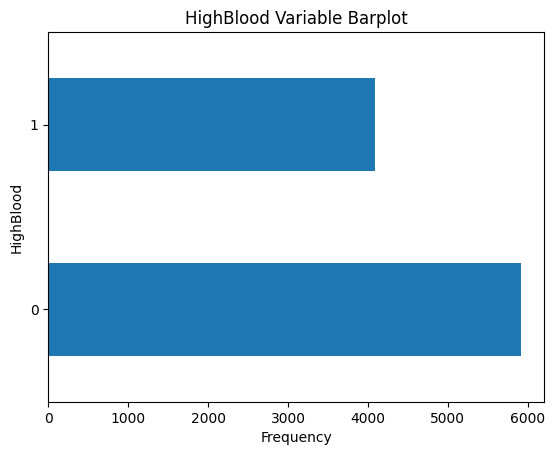

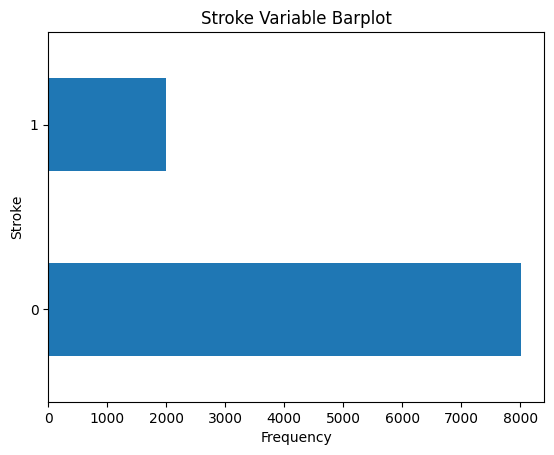

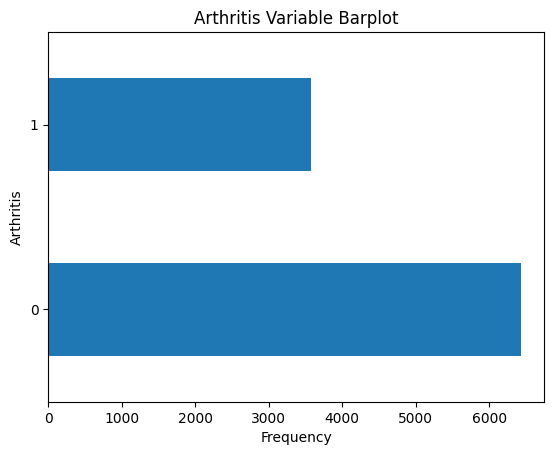

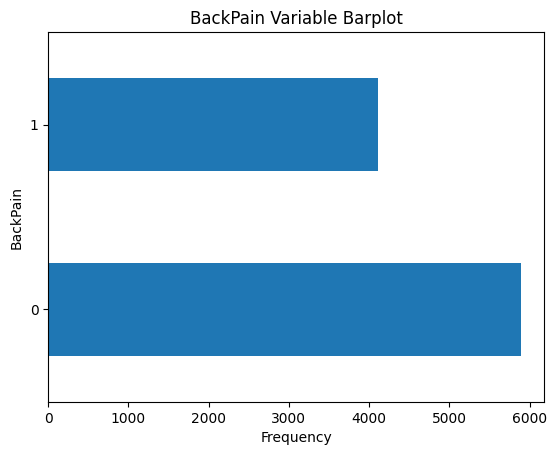

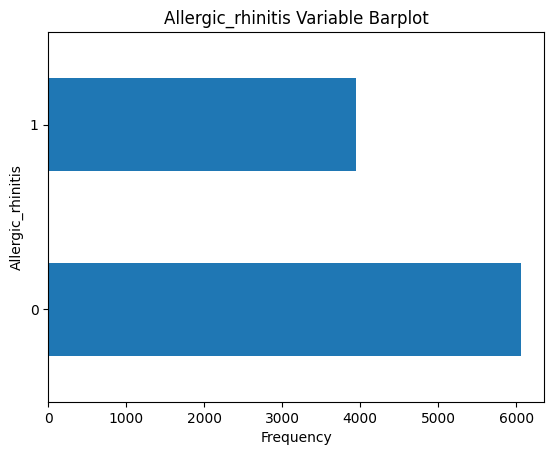

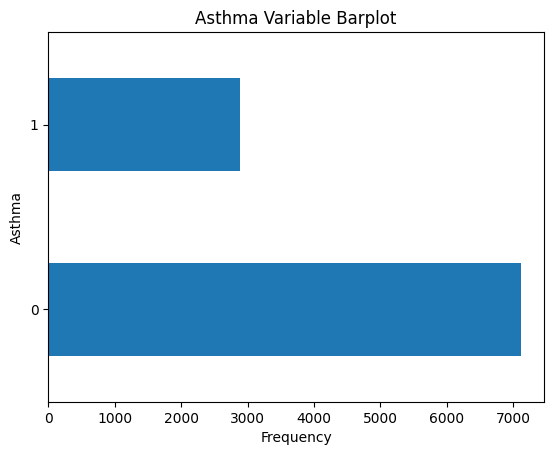

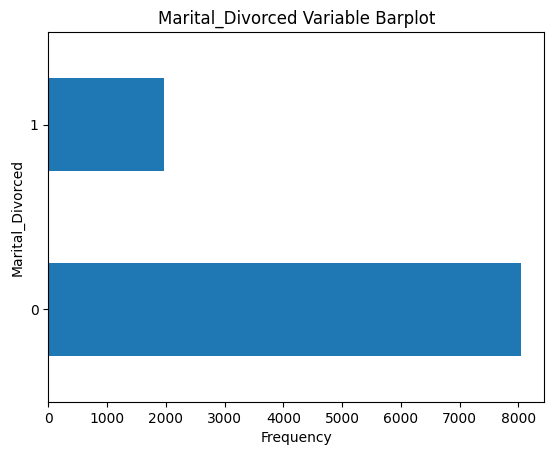

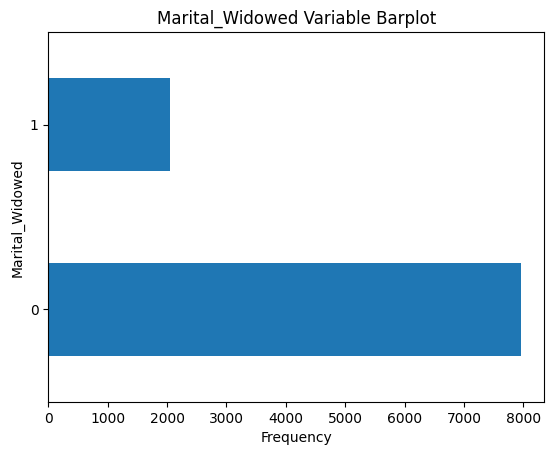

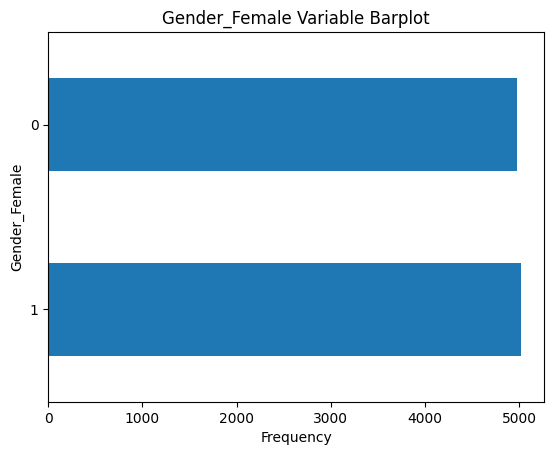

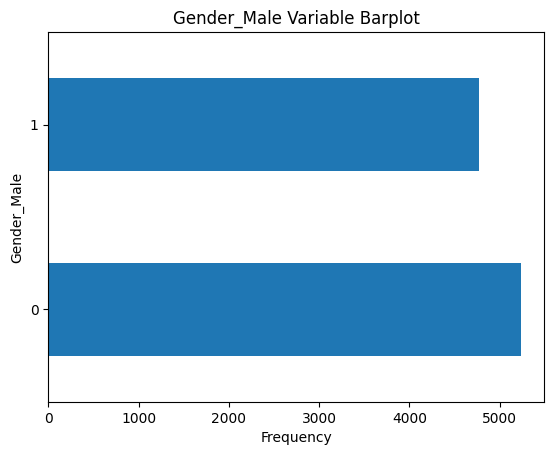

In [ ]:
# Univariate Analysis (visualization) - all categorical variables
# Bar plots are used to represent categorical data and display frequency of the data.

# Create a loop to plot each categorical variables on a horizontal bar plot
for var in cat_features:
    df_encoded[var].value_counts().plot(kind='barh')
    plt.title(var+' Variable Barplot')
    plt.xlabel('Frequency')
    plt.ylabel(var)
    plt.savefig(var+' Variable - Horizontal Barplot.png',bbox_inches='tight')
    plt.show()

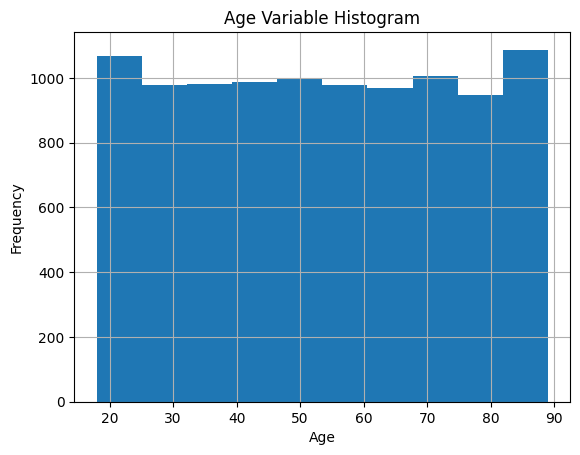

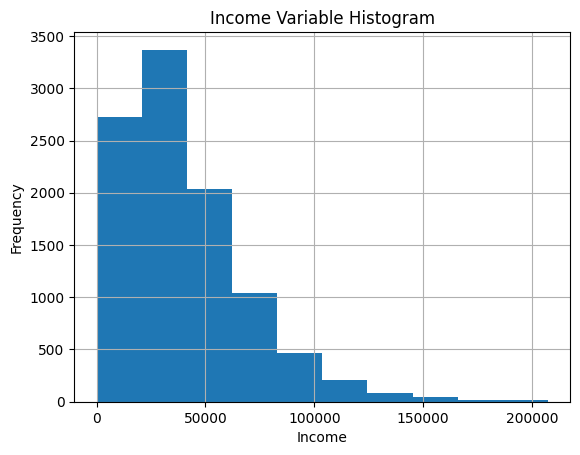

In [ ]:
# Univariate Analysis (visualization) - all numeric variables

# Create a loop to plot each numeric variables on a boxplot
for var in num_features:
    df_encoded[var].hist()
    plt.title(var+' Variable Histogram')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.savefig(var+' Variable - Histogram.png',bbox_inches='tight')
    plt.show()

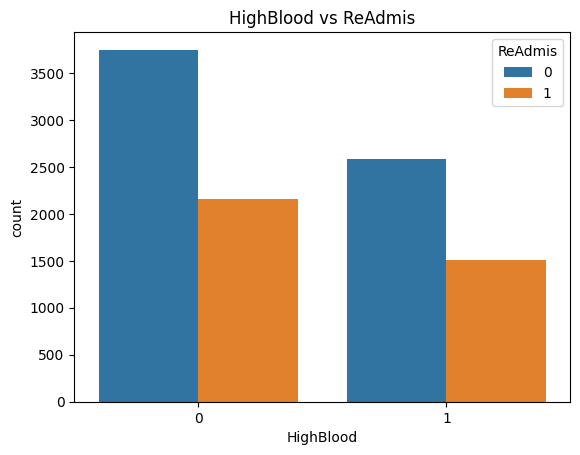

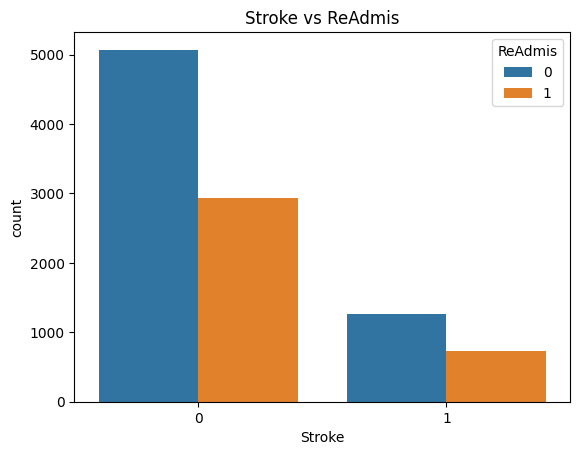

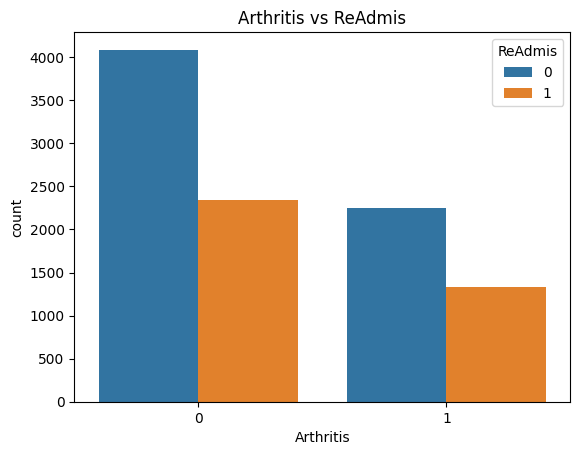

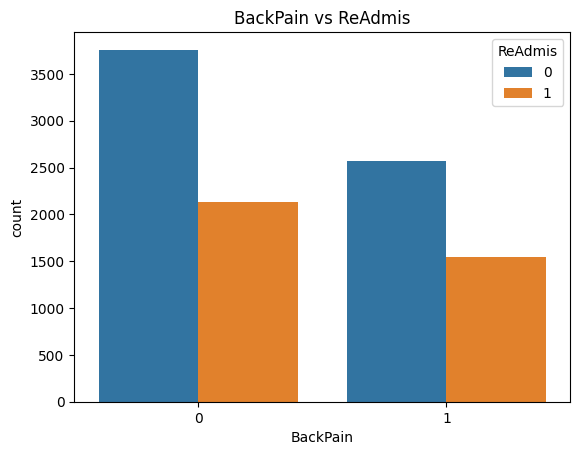

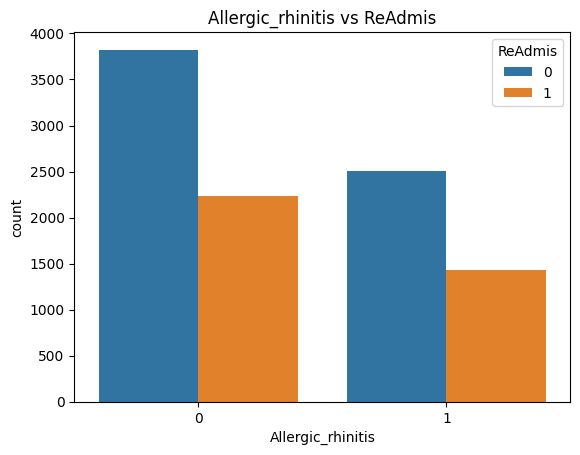

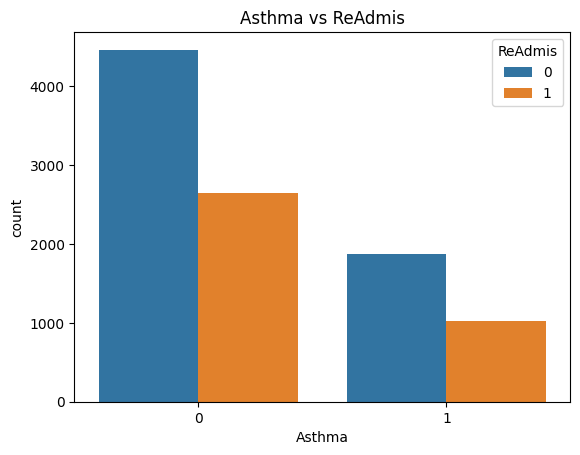

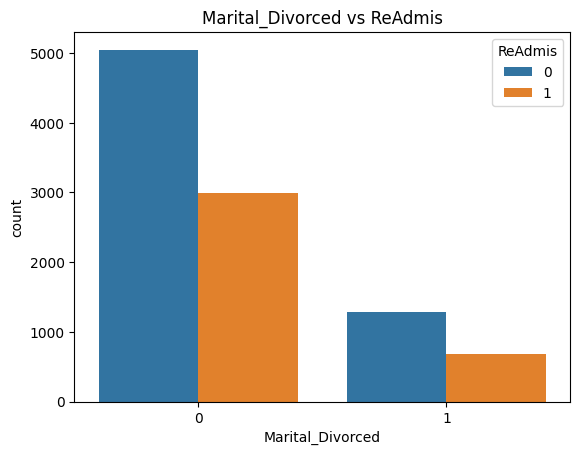

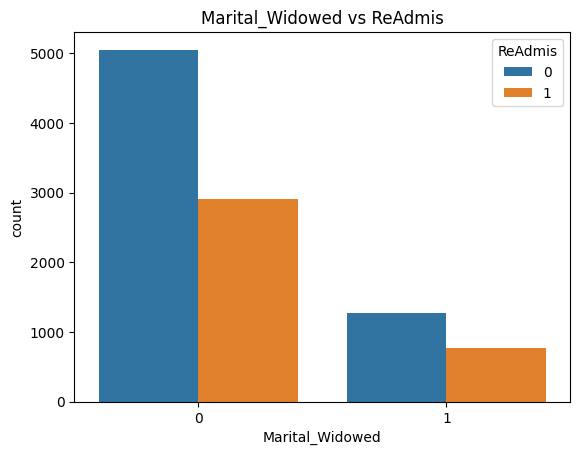

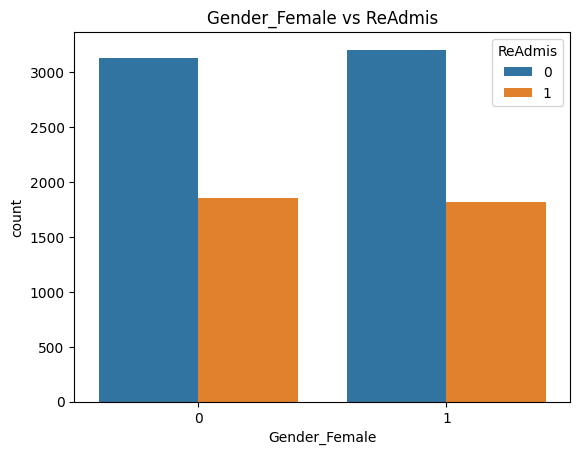

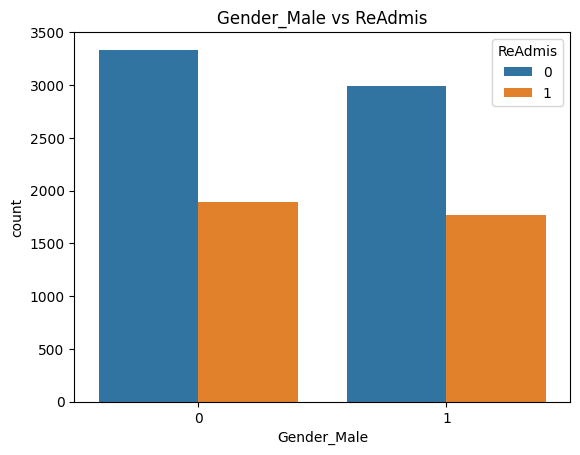

In [ ]:
# countplot comparing each categorical variable against the target variable
for var in cat_features:
    sns.countplot(data=df_encoded, x=var,hue='ReAdmis')
    plt.title(var+ ' vs ReAdmis')
    plt.savefig(var+ ' vs ReAdmis - Countplot.png')
    plt.show()

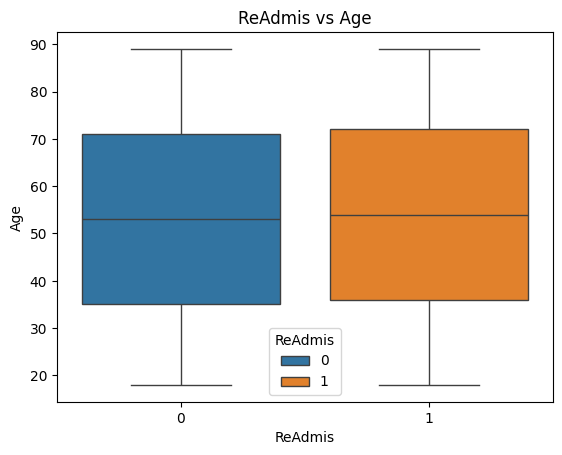

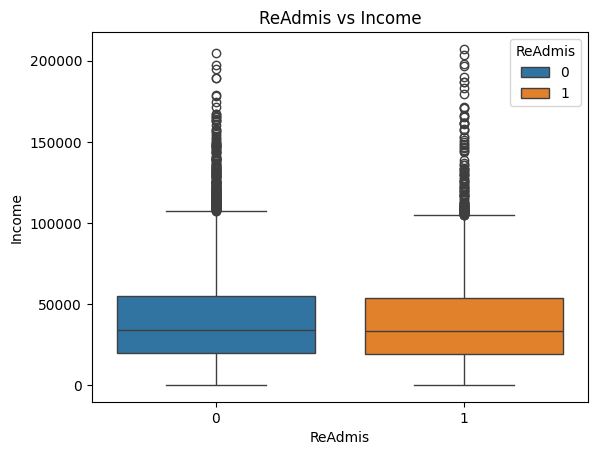

In [ ]:
for var in num_features:
    sns.boxplot(x = df_encoded['ReAdmis'],
                y = df_encoded[var],
               hue=df_encoded['ReAdmis'])
    plt.title('ReAdmis vs ' + var)
    plt.savefig('ReAdmis vs ' + var +'- Boxplot.png')
    plt.show()

### D2. OUTPUT AND INTERMEDIATE CALCULATIONS 

In [ ]:
# Unscaled KNN
knn= KNeighborsClassifier(metric='manhattan',n_neighbors=38, weights = 'distance')
knn_unscaled = knn.fit(X_train, y_train)
knn_unscaled_score = knn_unscaled.score(X_test, y_test)
print('KNN unscaled accuracy score: ', knn_unscaled_score)

KNN unscaled accuracy score:  0.606


In [ ]:
# Unscaled KNN
knn= KNeighborsClassifier(metric='manhattan',n_neighbors=49, weights = 'distance')
knn_unscaled = knn.fit(X_train, y_train)
knn_unscaled_score = knn_unscaled.score(X_test, y_test)
print('KNN unscaled accuracy score: ', knn_unscaled_score)

KNN unscaled accuracy score:  0.606


In [ ]:
# Initialize the scalar
scaler = StandardScaler()
numeric_features = ['Age','Income']

# Fit and transform the scaler on the train and testing data 
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

X_train.head()

,HighBlood,Stroke,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Age,Income,Area_Rural,Area_Suburban,Area_Urban,Marital_Divorced,Marital_Married,Marital_Never Married,Marital_Separated,Marital_Widowed,Gender_Female,Gender_Male,Gender_Nonbinary
4643,0,0,0,1,1,0,1,0,0,1,1,-0.514247,0.483446,0,0,1,0,0,1,0,0,1,0,0
2390,0,0,1,0,0,0,1,1,0,1,0,-0.272269,-0.047098,0,0,1,0,0,0,1,0,0,1,0
6162,1,0,1,0,0,1,0,0,0,0,1,-0.949809,0.615766,1,0,0,0,0,0,0,1,0,1,0
8678,1,0,1,0,0,0,0,0,0,1,1,-0.369060,2.169348,0,1,0,0,0,0,1,0,1,0,0
6944,0,0,0,0,1,1,1,1,1,1,0,0.114898,-0.962545,0,1,0,0,0,0,0,1,0,1,0


In [ ]:
X_test.head()

,HighBlood,Stroke,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Age,Income,Area_Rural,Area_Suburban,Area_Urban,Marital_Divorced,Marital_Married,Marital_Never Married,Marital_Separated,Marital_Widowed,Gender_Female,Gender_Male,Gender_Nonbinary
4132,1,0,1,0,0,1,0,1,0,1,0,1.469979,-1.081717,1,0,0,0,0,0,1,0,0,1,0
6553,0,0,1,0,0,1,0,0,1,0,1,-1.530558,-0.962995,0,1,0,0,0,1,0,0,0,1,0
7604,1,0,0,1,0,1,0,0,0,1,0,0.453668,-1.204763,0,0,1,0,0,0,1,0,0,1,0
585,0,0,1,0,1,0,0,0,0,1,0,0.211689,0.277267,0,1,0,0,1,0,0,0,1,0,0
5924,0,0,0,0,1,0,1,0,1,0,0,0.986021,-0.995462,0,0,1,0,1,0,0,0,0,1,0


In [ ]:
# Export the training and test data set to csv files
pd.DataFrame(X_train).to_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\6. K-Nearest Neighbors in Python for Data Mining\Outputs\X_train.csv",index=False)
pd.DataFrame(X_test).to_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\6. K-Nearest Neighbors in Python for Data Mining\Outputs\X_test.csv",index=False)
pd.DataFrame(y_train).to_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\6. K-Nearest Neighbors in Python for Data Mining\Outputs\y_train.csv",index=False)
pd.DataFrame(y_test).to_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\6. K-Nearest Neighbors in Python for Data Mining\Outputs\y_test.csv",index=False)

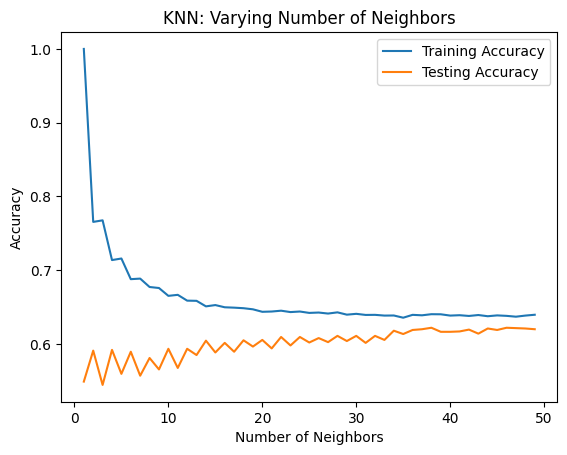

Number of neighbors for best accuracy:  38


In [ ]:
# Finding optimal model - model complexity curve
neighbors = np.arange(1,50)
train_accuracy = np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

# Create loop to test different k values
for i, k in enumerate(neighbors):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_accuracy[i] = knn.score(X_train, y_train)
    test_accuracy[i] = knn.score(X_test, y_test)

# Graph KNN - Varying the number of neighbors
plt.title('KNN: Varying Number of Neighbors')
plt.plot(neighbors, train_accuracy, label = 'Training Accuracy')
plt.plot(neighbors, test_accuracy, label = 'Testing Accuracy')
plt.legend()
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.savefig('KNN - Varing Number of Neighbors.png')
plt.show()

print('Number of neighbors for best accuracy: ', neighbors[np.argmax(test_accuracy)])

In [ ]:
# Cross validation
knn = KNeighborsClassifier(metric='manhattan', weights = 'distance')
knn = knn.fit(X_train,y_train)
params = {"n_neighbors": np.arange(1,50)}

cv = GridSearchCV(knn, param_grid=params)
cv.fit(X_train, y_train)
y_pred = cv.predict(X_test)

print('KNN scaled accuracy score: ', cv.best_score_)
print(cv.best_params_)

KNN scaled accuracy score:  0.630625
{'n_neighbors': 49}


In [ ]:
print('Change in accuracy: ', cv.best_score_-knn_unscaled_score)

Change in accuracy:  0.024625000000000008


In [ ]:
# Confusion matrix in scikit-learn
conf_matrix = confusion_matrix(y_test, y_pred)
print("The Confusion Matrix for KNN:")
print(conf_matrix)

The Confusion Matrix for KNN:
[[1204   47]
 [ 706   43]]


In [ ]:
# Classification report in scikit-learn
print("The Classification Report:")
print(classification_report(y_test, y_pred))

The Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.96      0.76      1251
           1       0.48      0.06      0.10       749

    accuracy                           0.62      2000
   macro avg       0.55      0.51      0.43      2000
weighted avg       0.57      0.62      0.51      2000



### E1. ACCURACY AND AUC

In [ ]:
TN = conf_matrix[0,0]
TP = conf_matrix[1,1]
FN = conf_matrix[1,0]
FP = conf_matrix[0,1]

print("True Negative:", TN)
print("False Positive:", FP)
print("False Negative:", FN)
print("True Positive:", TP)

True Negative: 1204
False Positive: 47
False Negative: 706
True Positive: 43


In [ ]:
total = TN + TP + FN + FP # 20% of the data was tested
false_pred = (FN + FP)/total
true_pred = (TN + TP)/total
fn_pred = FN/total
fp_pred = FP/total

print("Total Data Predictions:", total)

print("False Negative Predictions:", fn_pred)
print("False Postive Predictions:", fp_pred)

print("Total Inaccurate Predictions:", false_pred)
print("Total Accurate Predictions:", true_pred)

Total Data Predictions: 2000
False Negative Predictions: 0.353
False Postive Predictions: 0.0235
Total Inaccurate Predictions: 0.3765
Total Accurate Predictions: 0.6235


In [ ]:
# Calculate the accuracy
accuracy = (TN + TP) / (TN + TP + FN + FP)
print("Accuracy: ", accuracy)

# Calculate the sensitivity
sensitivity = TP / (FN + TP)
print("Sensitivity: ", sensitivity)

# Calculate the specificity
specificity = TN / (TN + FP)
print("Specificity: ", specificity)

Accuracy:  0.6235
Sensitivity:  0.05740987983978638
Specificity:  0.9624300559552358


In [ ]:
# ROC AUC in scikit-learn
y_prob = knn.predict_proba(X_test)[:, 1]
print("The ROC_AUC Score: ", roc_auc_score(y_test, y_prob))

The ROC_AUC Score:  0.5072129212517835


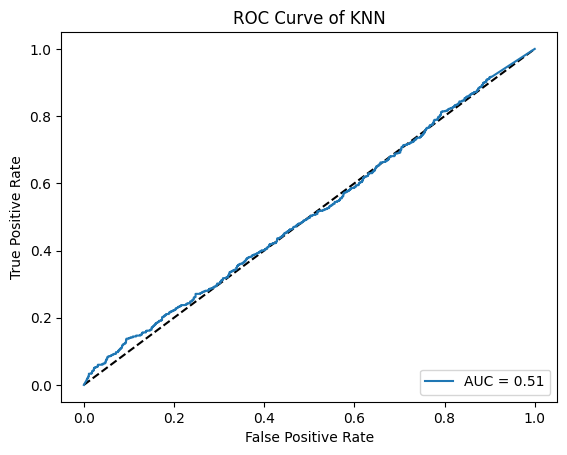

In [ ]:
# ROC Curve
y_pred_prob = knn.predict_proba(X_test)[:,1]
fpr,tpr, threshold = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr,tpr)

plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr,label='AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve of KNN')
plt.savefig('ROC Curve of KNN.png')
plt.show()

In [ ]:
# Comparing the training accuracy score to the testing accuracy score
print("Training Accuracy Score: ", cv.score(X_train,y_train))
print("Testing Accuracy Score: ", cv.score(X_test,y_test))

Training Accuracy Score:  1.0
Testing Accuracy Score:  0.6235


### E2. RESULTS AND IMPLICATIONS

The number of features were reduced from 24 to 12 variables using the feature selection method, SelectKBest. The following features were determined as key predictors: 'HighBlood', 'Stroke', 'Arthritis', 'BackPain', 'Allegic_rhinitis', 'Asthma', 'Age', 'Income', 'Marital_Divorced', 'Marital_Widowed','Gender_Female','Gender_Male'.

The accuracy was enhanced by approximately 1% with cross validation and hypertuning. However, the algorithm falsely predicted outcomes about 38% of the time as displayed in the confusion matrix. Incorporating more labeled data to train the model could further improve the performance and accuracy. 

In conclusion, the KNN classification method did not achieve the desired outcome of successfully predicting patient readmission. Although the training data had a perfect accuracy score, the testing set did not result in the same level of performance. 

### E3. LIMITATION
The medical data is unbalanced which may account for the algorithm's poor performance of the algorithm. Specifically, out of 10,000 observations, there were 6,331 instances of patients not being readmitted and 3,669 instances of patients being readmitted. This imbalance can skew the algorithm's predictions. Therefore, a more balanced dataset could potentially improve performance and enhance accuracy.

### E4. COURSE OF ACTION
An accuracy of 62% and AUC score of 0.5 suggests that the algorithm performed poorly at distinguishing between classes. Poor performance can be attributed to several factors, including class imbalance, limited data, and the selection of evaluation metrics. Incorporating additional patient information, such as the type of initial admission, the level of complication risk, and the services received, can provide more context and improve prediction accuracy. Enhancing the KNN model can also involve experimenting with different feature selection methods, optimizing the number of features to analyze, and adjusting more parameters. These improvements will contribute to a more thorough analysis, yield better performance, and help the organization achieve its goals more effectively.